# Deep Learning for Media
#### MPATE-GE 2039 - DM-GY 9103

---

# Hit Song Prediction Project

### Project Overview

This project introduces a deep learning pipeline aimed at predicting whether a song is likely to become a "hit" across four different eras: the 1980s, 1990s, 2000s, and 2010s. The objective is to build a multi-class classification model that leverages audio features obtained from the AcousticBrainz API, with song data collected by scraping the Billboard Top 100 website.



## Hit Song Prediction: A Multiclass Classification Model

Refer to `utils.py` for utility functions for data processing, model evaluation and script for extracting audio features from song data.

Refer to `model.py` for definition of the deep learning model architecture.






In [1]:
import librosa
import numpy as np
import pandas as pd
import soundfile as sf
import hashlib
from tensorflow import keras

from sklearn.metrics import classification_report

from sklearn.preprocessing import MinMaxScaler
import ast
import json

import utils as u
import models as m

# Upload Audio and extract its features.

## Part 1 - Load the Dataset and Split It

In this section, we prepare our model for predicting the hit era of songs by organizing and preprocessing the dataset. The dataset is created by:

* Scraping track names and artist names from the Billboard Hot 100 website.

*  Retrieving MusicBrainz Identifiers (MBIDs) for each track using the MusicBrainz API to ensure consistent song identification and avoid duplicates.

* Extracting audio features such as danceability, energy, loudness, and others from the AcousticBrainz API based on the MBIDs.

* Cleaning the data by dropping songs without MBIDs and removing duplicate songs, prioritizing those from older decades.

* Labeling songs according to their decade:

 * 1980s → label 0

 * 1990s → label 1

 * 2000s → label 2

 * 2010s → label 3

* Merging all songs into a single dataset covering the four decades.

* Expanding array-type features into multiple columns, normalizing feature values to a 0–1 range using Min-Max scaling, and filling missing or infinite values with zeros.

This processed dataset provides the foundation for training a deep learning model that predicts the likely hit decade of a song based on its audio characteristics.



In [2]:
# Fix the random seed for reproducibility
from numpy.random import seed
seed(124)
import tensorflow as tf
tf.keras.utils.set_random_seed(124)

### Import Json Files

In [3]:
csv_80s = "datasets/80s/billboard_80s_features_full.csv"
csv_90s = "datasets/90s/billboard_90s_features_full.csv"
csv_00s = "datasets/00s/billboard_00s_features_full.csv"
csv_10s = "datasets/10s/billboard_10s_features_full.csv"

## Features

In [4]:
features = [
    # # High-level genres and moods
    # "hl.highlevel.genre_dortmund.value",
    # "hl.highlevel.genre_rosamerica.value",
    # "hl.highlevel.genre_tzanetakis.value",
    # "hl.highlevel.moods_mirex.value",
    # "hl.highlevel.ismir04_rhythm.value",
    # "hl.highlevel.mood_acoustic.value",
    # "hl.highlevel.mood_aggressive.value",
    # "hl.highlevel.mood_electronic.value",
    # "hl.highlevel.mood_happy.value",
    # "hl.highlevel.mood_party.value",
    # "hl.highlevel.mood_relaxed.value",
    # "hl.highlevel.mood_sad.value",
    # "hl.highlevel.timbre.value",
    # "hl.highlevel.tonal_atonal.value",
    # "hl.highlevel.voice_instrumental.value",

    # Basic tonality and rhythm
    "ll.tonal.key_key",
    "ll.tonal.key_scale",
    "ll.tonal.key_strength",
    "ll.tonal.tuning_frequency",
    "ll.tonal.tuning_diatonic_strength",
    "ll.rhythm.bpm",
    "ll.rhythm.danceability",
    "ll.rhythm.beats_count",
    "ll.rhythm.onset_rate",

    # Chroma and HPCP
    #"ll.tonal.chroma.mean",
    "ll.tonal.hpcp.mean",

    # Low-level audio descriptors
    "ll.lowlevel.dynamic_complexity",
    "ll.lowlevel.average_loudness",

    # Spectral features
    "ll.lowlevel.spectral_centroid.mean",
    #"ll.lowlevel.spectral_bandwidth.mean",
    "ll.lowlevel.spectral_flux.mean",
    "ll.lowlevel.spectral_rolloff.mean",
    "ll.lowlevel.spectral_entropy.mean",
    "ll.lowlevel.spectral_complexity.mean",
    "ll.lowlevel.spectral_energy.mean",
    "ll.lowlevel.spectral_spread.mean",
    #"ll.lowlevel.spectral_flatness_db.mean",

    # MFCCs
    "ll.lowlevel.mfcc.mean",

    # Bark bands
    "ll.lowlevel.barkbands.mean",

    # Mel bands
    "ll.lowlevel.melbands.mean",

    # Zero Crossing Rate
    "ll.lowlevel.zerocrossingrate.mean",

    # Harmonic features
    "ll.lowlevel.pitch_salience.mean",

    # Energy bands
    "ll.lowlevel.spectral_energyband_low.mean",
    "ll.lowlevel.spectral_energyband_high.mean",
    "ll.lowlevel.spectral_energyband_middle_low.mean",
    "ll.lowlevel.spectral_energyband_middle_high.mean"
]

X, Y = u.csv_to_data(csv_80s, csv_90s, csv_00s, csv_10s, features)

   ll.lowlevel.average_loudness  ll.lowlevel.dynamic_complexity  \
0                      0.982230                        0.104587   
1                      0.925983                        0.072633   
2                      0.856262                        0.096715   
3                      0.913278                        0.091712   
4                      0.854097                        0.106798   

   ll.lowlevel.pitch_salience.mean  ll.lowlevel.spectral_centroid.mean  \
0                         0.658794                            0.115274   
1                         0.671963                            0.160915   
2                         0.702257                            0.057035   
3                         0.591956                            0.098206   
4                         0.738256                            0.129000   

   ll.lowlevel.spectral_complexity.mean  ll.lowlevel.spectral_energy.mean  \
0                              0.376330                          0.017003  

# Basic tonality and rhythm
    "ll.tonal.key_key",
    "ll.tonal.key_scale",
    "ll.tonal.key_strength",
    "ll.tonal.tuning_frequency",
    "ll.tonal.tuning_diatonic_strength",
    "ll.rhythm.bpm",
    "ll.rhythm.danceability",
    "ll.rhythm.beats_count",
    "ll.rhythm.onset_rate",    
    "ll.tonal.hpcp.mean",
    "ll.lowlevel.dynamic_complexity",
    "ll.lowlevel.average_loudness",
    "ll.lowlevel.spectral_centroid.mean",
    "ll.lowlevel.spectral_flux.mean",
    "ll.lowlevel.spectral_rolloff.mean",
    "ll.lowlevel.spectral_entropy.mean",
    "ll.lowlevel.spectral_complexity.mean",
    "ll.lowlevel.spectral_energy.mean",
    "ll.lowlevel.spectral_spread.mean",
    "ll.lowlevel.mfcc.mean",
    "ll.lowlevel.barkbands.mean",
    "ll.lowlevel.melbands.mean",
    "ll.lowlevel.zerocrossingrate.mean",
    "ll.lowlevel.pitch_salience.mean",
    "ll.lowlevel.spectral_energyband_low.mean",
    "ll.lowlevel.spectral_energyband_high.mean",
    "ll.lowlevel.spectral_energyband_middle_low.mean",
    "ll.lowlevel.spectral_energyband_middle_high.mean"
]

### Split the Dataset

In [5]:
# Split Data
X_train, Y_train, X_val, Y_val, X_test, Y_test = u.split_data_per_class(X, Y)

### Check for Dataset Overlaps

In [6]:
# Check overlaps
def hash_row(row):
    return hashlib.md5(row.tobytes()).hexdigest()

# Hash each sample
train_hashes = set([hash_row(x) for x in X_train])
val_hashes = set([hash_row(x) for x in X_val])
test_hashes = set([hash_row(x) for x in X_test])

# Check overlaps
overlap_train_val = train_hashes & val_hashes
overlap_train_test = train_hashes & test_hashes
overlap_val_test = val_hashes & test_hashes

print(f"Overlap between train and val: {len(overlap_train_val)} samples")
print(f"Overlap between train and test: {len(overlap_train_test)} samples")
print(f"Overlap between val and test: {len(overlap_val_test)} samples")

Overlap between train and val: 0 samples
Overlap between train and test: 0 samples
Overlap between val and test: 0 samples


In [7]:
# Check dimensions
print(X.shape, Y.shape, X_test.shape, Y_test.shape)

(6694, 151) (6694,) (667, 151) (667,)


In [8]:
# Check data dimensions X.shape==(samples, features)
print(X_train.shape, X_val.shape, Y_train.shape, Y_val.shape)

(5354, 151) (667, 151) (5354,) (667,)


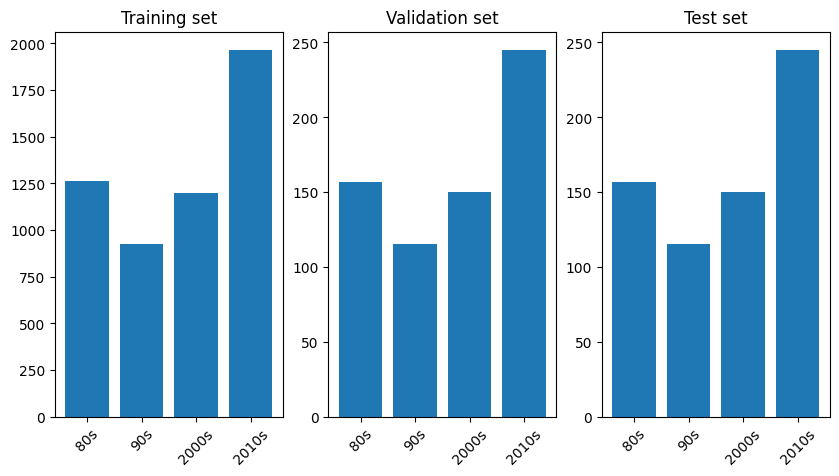

In [9]:
# Show dataset distribution
u.explore_data(X_train, Y_train, Y_test, Y_val)

### Detecting Missing or Infinite Data

In [10]:
# Check for NaNs and Infs
for name, data in zip(["X", "X_train", "X_val", "X_test"], [X, X_train, X_val, X_test]):
    data_float = np.array(data, dtype=np.float64)
    print(f"{name}: {np.isnan(data_float).sum()} NaNs")
    print(f"{name}: {np.isinf(data_float).sum()} Infs")

X: 0 NaNs
X: 0 Infs
X_train: 0 NaNs
X_train: 0 Infs
X_val: 0 NaNs
X_val: 0 Infs
X_test: 0 NaNs
X_test: 0 Infs


### Dataset Summary Statistics

In [11]:
# Check the data
print("X mean:", np.mean(X))
print("X std:", np.std(X))
print("X min:", np.min(X))
print("X max:", np.max(X))
print(np.bincount(Y.astype(int)))

X mean: 0.21091478250052467
X std: 0.20870661701948942
X min: 0.0
X max: 1.0000000000000002
[1577 1158 1501 2458]


# Build and Train a Baseline Model

### Build a Baseline Model for Decade Prediction



In [12]:
# Build baseline
baseline = m.build_baseline(X_train.shape[1])

### Train the Baseline Model

In [13]:
# Train model
model, history = m.train_model(baseline, X_train, Y_train,
                    epochs=10,
                    class_weights=None,
                    X_val=X_val, Y_val=Y_val)

Epoch 1/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4140 - loss: 1.2777 - val_accuracy: 0.5562 - val_loss: 1.0899
Epoch 2/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step - accuracy: 0.5381 - loss: 1.0774 - val_accuracy: 0.5757 - val_loss: 1.0461
Epoch 3/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 932us/step - accuracy: 0.5690 - loss: 1.0301 - val_accuracy: 0.5787 - val_loss: 1.0243
Epoch 4/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - accuracy: 0.5823 - loss: 1.0025 - val_accuracy: 0.5892 - val_loss: 1.0118
Epoch 5/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step - accuracy: 0.5952 - loss: 0.9807 - val_accuracy: 0.5907 - val_loss: 0.9969
Epoch 6/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 939us/step - accuracy: 0.6050 - loss: 0.9617 - val_accuracy: 0.5892 - val_loss: 0.9868
Epoch 7/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 946us/step - accuracy: 0.6088 - loss: 0.9454 - val_accuracy: 0.5937 - val_loss: 0.9771
Epoch 8/10
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - accuracy: 0.6218 - loss: 0.9304 - va

### Summarize Baseline Model Architecture

In [14]:
# Baseline check
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,918 (327.81 KB)

 Trainable params: 27,972 (109.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 55,946 (218.54 KB)

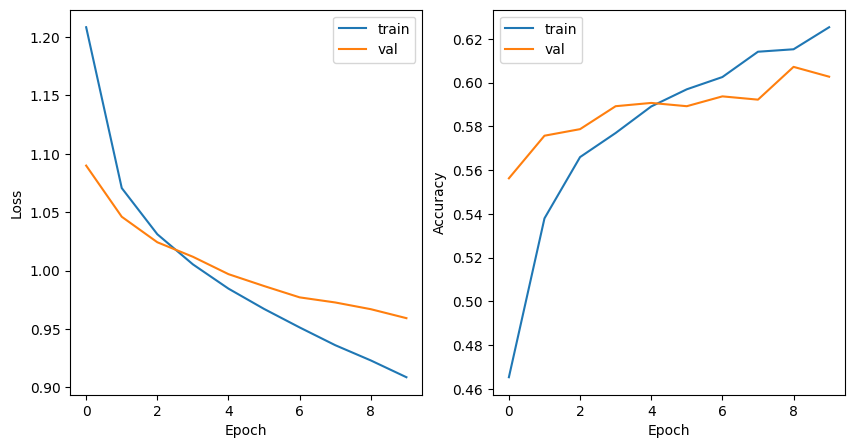

In [15]:
# Plot
u.plot_loss(history)

# Evaluate the Baseline Model

Since our task is to predict the correct decade (1980s, 1990s, 2000s, or 2010s) for a song based on its audio features, we focus on evaluating the overall classification accuracy and the distribution of predictions across all classes.

In other words:

* We want high overall accuracy, meaning the model correctly predicts the song's era most of the time.

* We aim for a balanced performance across all decades, avoiding bias toward any particular decade.

Model evaluation involves checking metrics such as accuracy, confusion matrix, and class-wise performance to ensure that the model reliably distinguishes between songs from different eras.

In [16]:
# Evaluate model
accuracy = u.evaluate_model(baseline, X_test, Y_test)
print(f"Accuracy: {accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Accuracy: 0.5652173913043478


In [17]:
# Predict labels for test data
Y_pred = np.argmax(baseline.predict(X_test), axis=1)

# Compute classification report
target_names = ["1980s", "1990s", "2000s", "2010s"]

report = classification_report(list(Y_test),
                               list(Y_pred),
                               target_names=target_names)

print(report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 854us/step
              precision    recall  f1-score   support

       1980s       0.57      0.82      0.67       157
       1990s       0.43      0.21      0.28       115
       2000s       0.40      0.19      0.25       150
       2010s       0.62      0.80      0.70       245

    accuracy                           0.57       667
   macro avg       0.51      0.50      0.48       667
weighted avg       0.53      0.57      0.52       667




# Build a Better Model

Now that we have a working baseline, the next step is to improve the model’s ability to accurately predict the decade a song belongs to, based on its audio features.

Our goals are to:

* Increase the overall classification accuracy across all four decades (80s, 90s, 00s, 10s).

* Achieve a balanced performance so that the model does not favor one decade over others.

To improve the model’s performance, we can try tuning various aspects:

* Modify the model architecture, such as adding more dense layers, increasing the number of units, or changing activation functions.

* Adjust the number of training epochs to better manage underfitting or overfitting.

* Experiment with regularization techniques (e.g., dropout, batch normalization) to improve generalization.

* Fine-tune learning rates or optimizers to enhance convergence during training.

Evaluation will focus primarily on overall accuracy and class-wise prediction performance, ensuring that the model reliably distinguishes between songs from different eras.


In [18]:
# Build a better model
model_1 = m.build_model(X_train.shape[1])

In [19]:
# Train model
class_weights = {0: 2.0,
                 1: 5.0,
                 2: 4.0,
                 3: 1.0
                }

model_1, history_1 = m.train_model(model_1, X_train, Y_train,
                    epochs=30,
                    class_weights=class_weights,
                    batch_size=64,
                    X_val=X_val, Y_val=Y_val)

Epoch 1/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2908 - loss: 4.7262 - val_accuracy: 0.2144 - val_loss: 1.4322
Epoch 2/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3250 - loss: 3.6825 - val_accuracy: 0.2444 - val_loss: 1.4464
Epoch 3/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3820 - loss: 3.3084 - val_accuracy: 0.2279 - val_loss: 1.4613
Epoch 4/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3795 - loss: 3.1138 - val_accuracy: 0.3088 - val_loss: 1.3830
Epoch 5/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4092 - loss: 3.0335 - val_accuracy: 0.3523 - val_loss: 1.3082
Epoch 6/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4324 - loss: 2.9385 - val_accuracy: 0.4228 - val_loss: 1.2572
Epoch 7/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4478 - loss: 2.8560 - val_accuracy: 0.4138 - val_loss: 1.3233
Epoch 8/30
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4587 - loss: 2.8188 - val_accuracy: 0.4528 - val_loss:

In [20]:
# Model check
model_1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 512)            │        77,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 759,374 (2.90 MB)

 Trainable params: 252,484 (986.27 KB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 504,970 (1.93 MB)

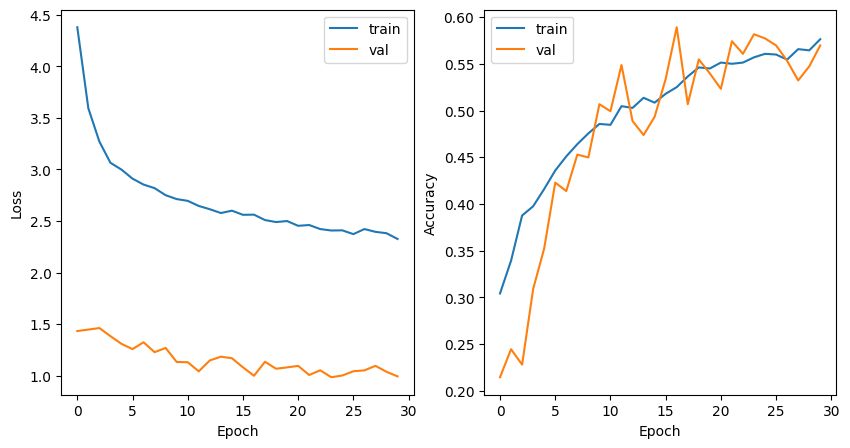

In [21]:
# Plot
u.plot_loss(history_1)

In [22]:
# Evaluate model
accuracy = u.evaluate_model(model_1, X_test, Y_test)
print(f"Accuracy: {accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.5517241379310345


In [23]:
# Predict labels for test data
Y_pred = np.argmax(model_1.predict(X_test), axis=1)

# Compute classification report
target_names = ["1980s", "1990s", "2000s", "2010s"]
report = classification_report(list(Y_test),
                               list(Y_pred),
                               target_names=target_names)

print(report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

       1980s       0.69      0.62      0.65       157
       1990s       0.40      0.38      0.39       115
       2000s       0.37      0.64      0.47       150
       2010s       0.82      0.53      0.65       245

    accuracy                           0.55       667
   macro avg       0.57      0.54      0.54       667
weighted avg       0.62      0.55      0.56       667



# Deeper MLP
We build a deeper multilayer perceptron (MLP) model by adding more dense layers with larger numbers of units, each followed by ReLU activation, batch normalization, and dropout regularization (30%). This deeper architecture increases the model's capacity to learn complex feature patterns, aiming to improve decade prediction accuracy compared to the baseline model. The model is trained using the Adam optimizer and categorical cross-entropy loss, with a softmax output layer for multi-class classification.

In [24]:
# Build model
model_2 = m.build_deeper_mlp(X_train.shape[1])

In [25]:
# Train model
class_weights = {0: 2.0,
                 1: 5.0,
                 2: 4.0,
                 3: 1.0
                }

model_2, history_2 = m.train_model(model_2, X_train, Y_train,
                    epochs=50,
                    class_weights=class_weights,
                    batch_size=64,
                    X_val=X_val, Y_val=Y_val)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 5s 37ms/step - accuracy: 0.2523 - loss: 5.2163 - val_accuracy: 0.1724 - val_loss: 1.4932
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.2585 - loss: 4.0604 - val_accuracy: 0.1724 - val_loss: 1.5255
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.2652 - loss: 3.6941 - val_accuracy: 0.1739 - val_loss: 1.5379
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.2723 - loss: 3.5264 - val_accuracy: 0.1829 - val_loss: 1.5147
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.2925 - loss: 3.3985 - val_accuracy: 0.2159 - val_loss: 1.4601
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.3147 - loss: 3.2850 - val_accuracy: 0.2699 - val_loss: 1.4263
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.3430 - loss: 3.2025 - val_accuracy: 0.3433 - val_loss: 1.3634
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.3638 - loss: 3.0914 - val_accuracy: 0.3988 - v

In [26]:
# Model check
model_2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 4096)           │       622,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 4096)           │        16,384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 35,498,030 (135.41 MB)

 Trainable params: 11,827,236 (45.12 MB)

 Non-trainable params: 16,320 (63.75 KB)

 Optimizer params: 23,654,474 (90.23 MB)

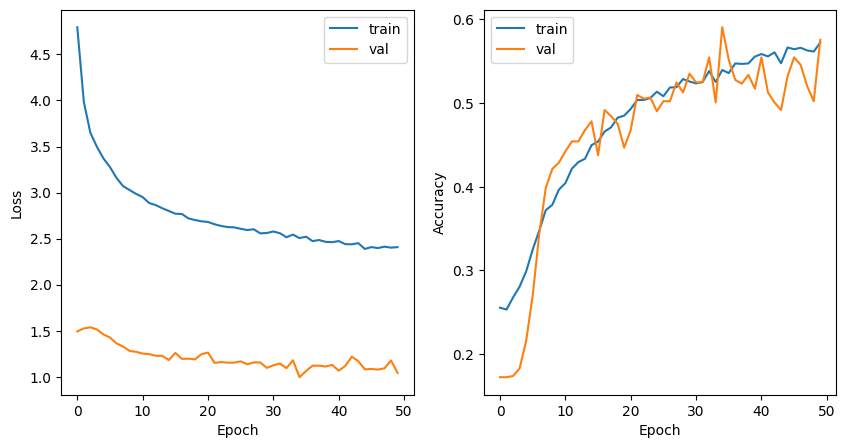

In [27]:
u.plot_loss(history_2)

In [28]:
# Evaluate model
accuracy = u.evaluate_model(model_2, X_test, Y_test)
print(f"Accuracy: {accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Accuracy: 0.553223388305847


In [29]:
# Predict labels for test data
Y_pred = np.argmax(model_2.predict(X_test), axis=1)

# Compute classification report
target_names = ["1980s", "1990s", "2000s", "2010s"]
report = classification_report(list(Y_test),
                               list(Y_pred),
                               target_names=target_names)

print(report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
              precision    recall  f1-score   support

       1980s       0.60      0.73      0.66       157
       1990s       0.41      0.46      0.43       115
       2000s       0.41      0.61      0.49       150
       2010s       0.87      0.45      0.59       245

    accuracy                           0.55       667
   macro avg       0.57      0.56      0.54       667
weighted avg       0.63      0.55      0.56       667



# Resnet MLP
We build a ResNet-inspired architecture using fully connected layers and residual connections to improve model performance. Each residual block contains a dense layer, batch normalization, and ReLU activation, with skip connections that allow the model to better propagate gradients during training. This structure helps address the vanishing gradient problem and enables deeper networks to train more effectively. The model uses the Adam optimizer and categorical cross-entropy loss, with a softmax output layer for decade classification.

In [30]:
# Build model
model_3 = m.build_resnet_mlp(X_train.shape[1])

In [31]:
# Train model
class_weights = {0: 2.0,
                 1: 5.0,
                 2: 4.0,
                 3: 1.0
                }

model_3, history_3 = m.train_model(model_3, X_train, Y_train,
                    epochs=50,
                    class_weights=class_weights,
                    batch_size=64,
                    X_val=X_val, Y_val=Y_val)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3030 - loss: 4.6918 - val_accuracy: 0.3898 - val_loss: 1.3545
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3919 - loss: 3.4922 - val_accuracy: 0.3118 - val_loss: 1.3986
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4276 - loss: 3.1489 - val_accuracy: 0.3298 - val_loss: 1.3973
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4433 - loss: 2.9700 - val_accuracy: 0.3658 - val_loss: 1.3186
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4789 - loss: 2.7617 - val_accuracy: 0.4138 - val_loss: 1.2196
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4879 - loss: 2.7151 - val_accuracy: 0.4753 - val_loss: 1.1725
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5173 - loss: 2.6545 - val_accuracy: 0.5067 - val_loss: 1.1277
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5257 - loss: 2.5440 - val_accuracy: 0.5247 - val_loss:

In [32]:
# Model check
model_3.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 151)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 256)       │     38,912 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_17[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 256)       │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_18[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ batch_normalizat… │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 256)       │          0 │ add[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 128)       │     32,896 │ dropout_12[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_19[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_20[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 4)         │        260 │ dropout_13[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 443,982 (1.69 MB)

 Trainable params: 147,524 (576.27 KB)

 Non-trainable params: 1,408 (5.50 KB)

 Optimizer params: 295,050 (1.13 MB)

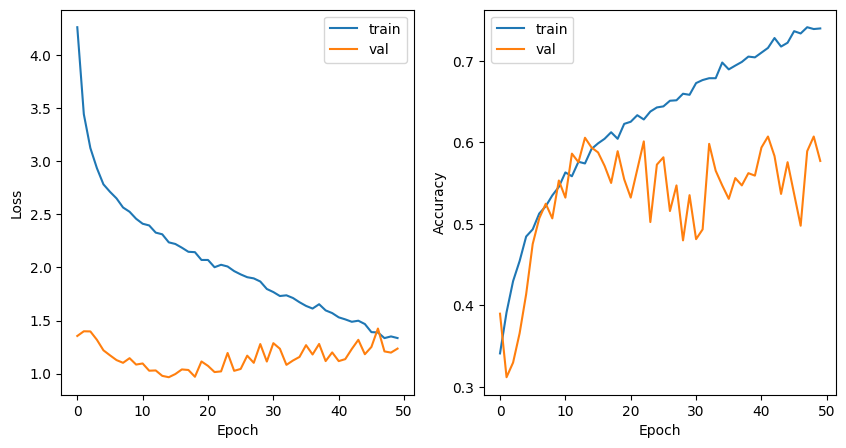

In [33]:
# Plot
u.plot_loss(history_3)

In [34]:
# Evaluate model
accuracy = u.evaluate_model(model_3, X_test, Y_test)
print(f"Accuracy: {accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.5652173913043478


In [35]:
# Predict labels for test data
Y_pred = np.argmax(model_3.predict(X_test), axis=1)

# Compute classification report
target_names = ["1980s", "1990s", "2000s", "2010s"]
report = classification_report(list(Y_test),
                               list(Y_pred),
                               target_names=target_names)

print(report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

       1980s       0.65      0.64      0.64       157
       1990s       0.38      0.47      0.42       115
       2000s       0.42      0.52      0.47       150
       2010s       0.78      0.59      0.67       245

    accuracy                           0.57       667
   macro avg       0.56      0.55      0.55       667
weighted avg       0.60      0.57      0.58       667



# Transformer Encoder
We build a Transformer Encoder model to better capture relationships between audio features. The model uses multi-head self-attention layers and position-wise feedforward networks to learn complex dependencies across the feature space. Although the input is tabular, the Transformer treats features as a sequence, allowing it to model interactions between different attributes. The model is trained with the Adam optimizer and categorical cross-entropy loss, and uses a softmax output layer for multi-class decade prediction.

In [36]:
# Build model
model_4 = m.build_transformer_encoder(X_train.shape[1])

In [37]:
# Train model
class_weights = {0: 2.0,
                 1: 5.0,
                 2: 4.0,
                 3: 1.0}

model_4, history_4 = m.train_model(model_4, X_train, Y_train,
                    epochs=50,
                    class_weights=class_weights,
                    batch_size=64,
                    X_val=X_val, Y_val=Y_val)

Epoch 1/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2289 - loss: 4.0363 - val_accuracy: 0.3703 - val_loss: 1.3144
Epoch 2/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3345 - loss: 3.2324 - val_accuracy: 0.4138 - val_loss: 1.2370
Epoch 3/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3745 - loss: 3.0350 - val_accuracy: 0.4618 - val_loss: 1.2111
Epoch 4/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4235 - loss: 2.9243 - val_accuracy: 0.4663 - val_loss: 1.1833
Epoch 5/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4410 - loss: 2.8647 - val_accuracy: 0.4603 - val_loss: 1.1785
Epoch 6/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4425 - loss: 2.8082 - val_accuracy: 0.4498 - val_loss: 1.1890
Epoch 7/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4718 - loss: 2.7840 - val_accuracy: 0.4453 - val_loss: 1.1956
Epoch 8/50
84/84 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4790 - loss: 2.7246 - val_accuracy: 0.4468 - val_loss:

In [38]:
# Model check
model_4.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 151)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_22 (Dense)    │ (None, 128)       │     19,456 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128)       │        256 │ dense_22[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 1, 128)    │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 1, 128)    │          0 │ layer_normalizat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 1, 128)    │          0 │ layer_normalizat… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 128)    │     66,048 │ get_item[0][0],   │
│ (MultiHeadAttentio… │                   │            │ get_item_1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 128)    │          0 │ get_item_2[0][0], │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 128)    │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 128)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 128)       │          0 │ flatten[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_23 (Dense)    │ (None, 64)        │      8,256 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_24 (Dense)    │ (None, 4)         │        260 │ dense_23[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 283,598 (1.08 MB)

 Trainable params: 94,532 (369.27 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 189,066 (738.54 KB)

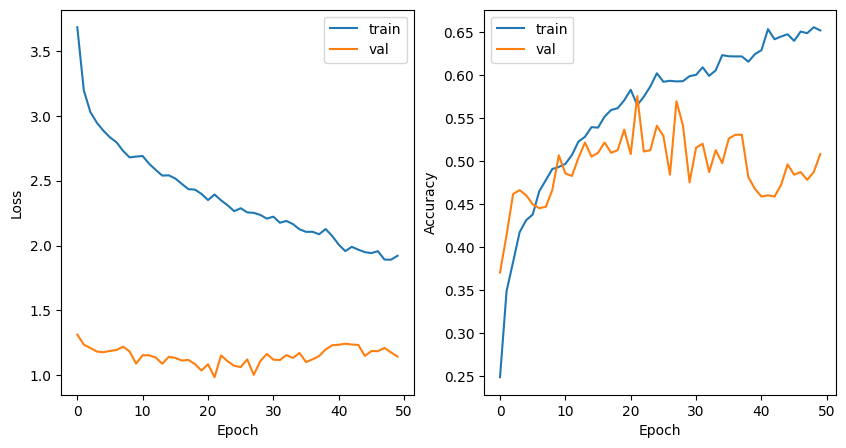

In [39]:
# Plot
u.plot_loss(history_4)

In [40]:
# Evaluate model
accuracy = u.evaluate_model(model_4, X_test, Y_test)
print(f"Accuracy: {accuracy}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Accuracy: 0.52023988005997


In [41]:
# Predict labels for test data
Y_pred = np.argmax(model_4.predict(X_test), axis=1)

# Compute classification report
target_names = ["1980s", "1990s", "2000s", "2010s"]
report = classification_report(list(Y_test),
                               list(Y_pred),
                               target_names=target_names)

print(report)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
              precision    recall  f1-score   support

       1980s       0.72      0.52      0.60       157
       1990s       0.37      0.40      0.38       115
       2000s       0.35      0.69      0.47       150
       2010s       0.86      0.47      0.61       245

    accuracy                           0.52       667
   macro avg       0.57      0.52      0.52       667
weighted avg       0.63      0.52      0.54       667



# Usage
We upload a AI generated music .wav file to the model for prediction.


In [42]:
audio_to_extract = "Generated_demo.wav"

### For MacOS Users:

In [43]:
!chmod +x extractors/streaming_extractor_music

In [45]:
audio_path = f"{audio_to_extract}"
config_path = "my_music_profile.yaml"
output_path = "features.json"

cmd = f'extractors/streaming_extractor_music "{audio_path}" "{output_path}" "{config_path}"'

!{cmd}

Process step: Read metadata
Process step: Compute md5 audio hash and codec
Process step: Replay gain
Process step: Compute audio features
Process step: Compute aggregation
All done
Writing results to file features.json


### For Windows OS Users:

In [ ]:
audio_path = f"/Users/atlyk/Desktop/deep_learning_media/final_project/041325-AtiUpdate/{audio_to_extract}"
config_path = "/Users/atlyk/Desktop/deep_learning_media/final_project/041325-AtiUpdate/my_music_profile.yaml"
output_path = "/Users/atlyk/Desktop/deep_learning_media/final_project/041325-AtiUpdate/features.txt"

cmd = f'/Users/atlyk/Desktop/deep_learning_media/final_project/041325-AtiUpdate/extractors/streaming_#extractor_music.exe "{audio_path}" "{output_path}" "{config_path}"'

!{cmd}

# Export to .csv file:
The audio features from the uploaded music (.wav) file re extracted and exported to a .csv file for importing into the model.

In [47]:
def flatten_dict(d, parent_key='', sep='.'):
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)

# --- Your desired feature order ---
features = [
    "ll.lowlevel.average_loudness",
    "ll.lowlevel.dynamic_complexity",
    "ll.lowlevel.pitch_salience.mean",
    "ll.lowlevel.spectral_centroid.mean",
    "ll.lowlevel.spectral_complexity.mean",
    "ll.lowlevel.spectral_energy.mean",
    "ll.lowlevel.spectral_energyband_high.mean",
    "ll.lowlevel.spectral_energyband_low.mean",
    "ll.lowlevel.spectral_energyband_middle_high.mean",
    "ll.lowlevel.spectral_energyband_middle_low.mean",
    "ll.lowlevel.spectral_entropy.mean",
    "ll.lowlevel.spectral_flux.mean",
    "ll.lowlevel.spectral_rolloff.mean",
    "ll.lowlevel.spectral_spread.mean",
    "ll.lowlevel.zerocrossingrate.mean",
    "ll.rhythm.beats_count",
    "ll.rhythm.bpm",
    "ll.rhythm.danceability",
    "ll.rhythm.onset_rate",
    "ll.tonal.key_scale",
    "ll.tonal.key_strength",
    "ll.tonal.tuning_diatonic_strength",
    "ll.tonal.tuning_frequency",
    "ll.tonal.key_key",
    "ll.tonal.hpcp.mean",
    "ll.lowlevel.mfcc.mean",
    "ll.lowlevel.barkbands.mean",
    "ll.lowlevel.melbands.mean",
]

# 1) Load your JSON
with open('features.json', 'r') as f:
    data = json.load(f)

# 2) Flatten each section with the correct prefix
hl = flatten_dict(data.get('highlevel', {}), parent_key='hl.highlevel')
ll_lowlevel = flatten_dict(data.get('lowlevel', {}), parent_key='ll.lowlevel')
ll_tonal = flatten_dict(data.get('tonal', {}), parent_key='ll.tonal')
ll_rhythm = flatten_dict(data.get('rhythm', {}), parent_key='ll.rhythm')

# 3) Merge into one flat row
row = {}
row.update(hl)
row.update(ll_lowlevel)
row.update(ll_tonal)
row.update(ll_rhythm)

# --- Drop bpm_histogram columns from row ---
row = {k: v for k, v in row.items() if "bpm_histogram" not in k}

# 4) Create DataFrame
df = pd.DataFrame([row])

# 5) Build keep_cols according to your features list (including expansions)
keep_cols = []
for feat in features:
    matched_cols = [col for col in df.columns if col == feat or col.startswith(feat + "_")]
    keep_cols.extend(matched_cols)

# --- Apply the column ordering ---
df = df[keep_cols]

# 6) Save
df.to_csv('features.csv', index=False)

print("✅ Exported → features.csv with correct order")

✅ Exported → features.csv with correct order


### Aimed Order

ll.lowlevel.average_loudness
ll.lowlevel.dynamic_complexity
ll.lowlevel.pitch_salience.mean
ll.lowlevel.spectral_centroid.mean
ll.lowlevel.spectral_complexity.mean
ll.lowlevel.spectral_energy.mean
ll.lowlevel.spectral_energyband_high.mean
ll.lowlevel.spectral_energyband_low.mean
ll.lowlevel.spectral_energyband_middle_high.mean
ll.lowlevel.spectral_energyband_middle_low.mean
ll.lowlevel.spectral_entropy.mean
ll.lowlevel.spectral_flux.mean
ll.lowlevel.spectral_rolloff.mean
ll.lowlevel.spectral_spread.mean
ll.lowlevel.zerocrossingrate.mean
ll.rhythm.beats_count
ll.rhythm.bpm
ll.rhythm.danceability
ll.rhythm.onset_rate
ll.tonal.key_scale
ll.tonal.key_strength
ll.tonal.tuning_diatonic_strength
ll.tonal.tuning_frequency
ll.tonal.key_key
ll.tonal.hpcp.mean
ll.lowlevel.mfcc.mean
ll.lowlevel.barkbands.mean
ll.lowlevel.melbands.mean

### Order of the columns in the features.csv

In [48]:
# Order of the columns in the features.csv
for col in df.columns:
    print(col)

ll.lowlevel.average_loudness
ll.lowlevel.dynamic_complexity
ll.lowlevel.pitch_salience.mean
ll.lowlevel.spectral_centroid.mean
ll.lowlevel.spectral_complexity.mean
ll.lowlevel.spectral_energy.mean
ll.lowlevel.spectral_energyband_high.mean
ll.lowlevel.spectral_energyband_low.mean
ll.lowlevel.spectral_energyband_middle_high.mean
ll.lowlevel.spectral_energyband_middle_low.mean
ll.lowlevel.spectral_entropy.mean
ll.lowlevel.spectral_flux.mean
ll.lowlevel.spectral_rolloff.mean
ll.lowlevel.spectral_spread.mean
ll.lowlevel.zerocrossingrate.mean
ll.rhythm.beats_count
ll.rhythm.bpm
ll.rhythm.danceability
ll.rhythm.onset_rate
ll.tonal.key_scale
ll.tonal.key_strength
ll.tonal.tuning_diatonic_strength
ll.tonal.tuning_frequency
ll.tonal.key_key
ll.tonal.hpcp.mean
ll.lowlevel.mfcc.mean
ll.lowlevel.barkbands.mean
ll.lowlevel.melbands.mean


In [49]:
features = [
    "ll.lowlevel.average_loudness",
    "ll.lowlevel.dynamic_complexity",
    "ll.lowlevel.pitch_salience.mean",
    "ll.lowlevel.spectral_centroid.mean",
    "ll.lowlevel.spectral_complexity.mean",
    "ll.lowlevel.spectral_energy.mean",
    "ll.lowlevel.spectral_energyband_high.mean",
    "ll.lowlevel.spectral_energyband_low.mean",
    "ll.lowlevel.spectral_energyband_middle_high.mean",
    "ll.lowlevel.spectral_energyband_middle_low.mean",
    "ll.lowlevel.spectral_entropy.mean",
    "ll.lowlevel.spectral_flux.mean",
    "ll.lowlevel.spectral_rolloff.mean",
    "ll.lowlevel.spectral_spread.mean",
    "ll.lowlevel.zerocrossingrate.mean",
    "ll.rhythm.beats_count",
    "ll.rhythm.bpm",
    "ll.rhythm.danceability",
    "ll.rhythm.onset_rate",
    "ll.tonal.key_scale",
    "ll.tonal.key_strength",
    "ll.tonal.tuning_diatonic_strength",
    "ll.tonal.tuning_frequency",
    "ll.tonal.key_key",
    "ll.tonal.hpcp.mean",
    "ll.lowlevel.mfcc.mean",
    "ll.lowlevel.barkbands.mean",
    "ll.lowlevel.melbands.mean",
]

In [50]:
# Load raw CSV
song_csv = "features.csv"
df = pd.read_csv(song_csv, low_memory=False)

# --- Step 1: Save the 'll.tonal.key_key' column separately ---
if "ll.tonal.key_key" in df.columns:
    key_key_col = df["ll.tonal.key_key"].copy()
else:
    key_key_col = None

# --- Step 2: Normalize other features ---
song = u.normalize_features(df, features)

# print(song.shape)
# for col in song.columns:
#     print(col)

## Predict

### Model 1

In [51]:
# Your class names
class_names = ["1980s", "1990s", "2000s", "2010s"]

# Predict
prediction_1 = model_1.predict(song)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [52]:
# Print each class probability in percentage format
for i, prob in enumerate(prediction_1[0]):
    print(f"{class_names[i]}: %{int(round(prob * 100))}")

# Check maximum probability
max_prob = prediction_1.max()

if max_prob < 0.60:
    print("❌ This song would never be a hit.")
else:
    predicted_class_idx = prediction_1.argmax(axis=1)[0]
    predicted_class_name = class_names[predicted_class_idx]
    print(f"\nThis song would be a hit song if it was released in the {predicted_class_name}.")

1980s: %0
1990s: %0
2000s: %0
2010s: %100

This song would be a hit song if it was released in the 2010s.


### Model 2

In [53]:
prediction_2 = model_2.predict(song)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


In [54]:
# Print each class probability in percentage format
for i, prob in enumerate(prediction_2[0]):
    print(f"{class_names[i]}: %{int(round(prob * 100))}")

# Check maximum probability
max_prob = prediction_2.max()

if max_prob < 0.60:
    print("❌ This song would never be a hit.")
else:
    predicted_class_idx = prediction_2.argmax(axis=1)[0]
    predicted_class_name = class_names[predicted_class_idx]
    print(f"\nThis song would be a hit song if it was released in the {predicted_class_name}.")

1980s: %0
1990s: %0
2000s: %0
2010s: %100

This song would be a hit song if it was released in the 2010s.


### Model 3

In [55]:
prediction_3 = model_3.predict(song)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [56]:
# Print each class probability in percentage format
for i, prob in enumerate(prediction_3[0]):
    print(f"{class_names[i]}: %{int(round(prob * 100))}")

# Check maximum probability
max_prob = prediction_3.max()

if max_prob < 0.60:
    print("❌ This song would never be a hit.")
else:
    predicted_class_idx = prediction_3.argmax(axis=1)[0]
    predicted_class_name = class_names[predicted_class_idx]
    print(f"\nThis song would be a hit song if it was released in the {predicted_class_name}.")

1980s: %0
1990s: %0
2000s: %0
2010s: %100

This song would be a hit song if it was released in the 2010s.


### Model 4

In [57]:
prediction_4 = model_4.predict(song)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step


In [58]:
# Print each class probability in percentage format
for i, prob in enumerate(prediction_4[0]):
    print(f"{class_names[i]}: %{int(round(prob * 100))}")

# Check maximum probability
max_prob = prediction_4.max()

if max_prob < 0.60:
    print("❌ This song would never be a hit.")
else:
    predicted_class_idx = prediction_4.argmax(axis=1)[0]
    predicted_class_name = class_names[predicted_class_idx]
    print(f"\nThis song would be a hit song if it was released in the {predicted_class_name}.")

1980s: %0
1990s: %0
2000s: %0
2010s: %100

This song would be a hit song if it was released in the 2010s.
